## 5. Robustness Check

In [1]:
import pandas as pd

# load cleaned data
df = pd.read_csv("../data/processed/data_cleaned.csv")
df.shape

(3596, 13)

In [2]:
df.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,profession_clean,party_clean,text_lemma
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,Other,Other,science po fonds cevipof république français l...
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,Health,Union pour une nouvelle majorité,science po fonds cevipof Jean VIAL an docteur ...
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,Health,Union pour une nouvelle majorité,republique français troisieme circonscription ...
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,Education,Other,élection législatif juin circonscription AISNE...
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,Other,Union pour une nouvelle majorité,science po fonds cevipof Lucien BOCHARD electi...


In [3]:
df['party_clean'].value_counts()

party_clean
Other                                          864
Liste d'entente populaire et nationale         450
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64

In [4]:
df['profession_clean'].value_counts()

profession_clean
Other          1454
Education       617
Health          303
Business        300
Technical       278
Law             195
Worker          188
Agriculture     111
Political        95
Media            55
Name: count, dtype: int64

In [5]:
from sklearn.decomposition import LatentDirichletAllocation
import statsmodels.formula.api as smf
import pandas as pd

def run_topic_regression(X, df_meta, k):

    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch'
    )

    doc_topics = lda.fit_transform(X)

    df_topics = pd.DataFrame(doc_topics, columns=[f"Topic_{i}" for i in range(k)])

    df_model = pd.concat([df_meta.reset_index(drop=True), df_topics], axis=1)

    party_r2 = []
    prof_r2 = []

    for t in range(k):

        formula = f"Topic_{t} ~ C(party_clean) + C(profession_clean) + C(year)"
        model = smf.ols(formula, data=df_model).fit()

        r2_full = model.rsquared

        model_no_party = smf.ols(
            f"Topic_{t} ~ C(profession_clean) + C(year)",
            data=df_model
        ).fit()

        model_no_prof = smf.ols(
            f"Topic_{t} ~ C(party_clean) + C(year)",
            data=df_model
        ).fit()

        party_r2.append(r2_full - model_no_party.rsquared)
        prof_r2.append(r2_full - model_no_prof.rsquared)

    return sum(party_r2)/k, sum(prof_r2)/k

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

from nltk.corpus import stopwords

french_stopwords = set(stopwords.words('french'))
extra_stopwords = {

    # Archive artifacts
    "cevipof","fonds",

    # Election formatting
    "circonscription","elections","législatives","tour",

    # Candidate biography
    "candidat","candidats","suppléant","suppléants",
    "maire","conseiller","ans",

    # Weak rhetorical words
    "comme","contre","faire","fait","faut",
    "ceux","leurs","depuis","tout","tous",
    "être","falloir","vouloir","mettre","donner",

    # OCR artifacts (German)
    "die","der","und","für","den","sie","eine","das",
    "wir","werden","auf","nicht","einer","dass","gegen",
    "ihr","auch","mit","von","ist","dem","ein","ich",
    "sich","wird","haben","durch","ihre","als",
    "frankreich","leben","sind","mehr","einen","politik",
    "mehrheit","hat","geben","juni","werden","nicht",

    # Geographic artifacts
    "alsace","strasbourg",

    # Formatting tokens
    "mai","juin","mars",
    "monsieur","madame","mademoiselle",
}

# Combine stopwords
all_stopwords = list(french_stopwords.union(extra_stopwords))

vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',
    max_df=0.95,
    min_df=20
)

X = vectorizer.fit_transform(df['text_lemma'])

In [7]:
# baseline regression
baseline_party, baseline_prof = run_topic_regression(X, df, 10)
print(baseline_party, baseline_prof)

0.407249592906064 0.005021216234000403


In [8]:
# robustness check: vary number of topics
results_topics = []

for k in [8,10,12,15,20]:

    party_r2, prof_r2 = run_topic_regression(X, df, k)

    results_topics.append({
        "topics":k,
        "party_r2":party_r2,
        "profession_r2":prof_r2
    })

results_topics_df = pd.DataFrame(results_topics)
results_topics_df

,topics,party_r2,profession_r2
0,8,0.403628,0.004931
1,10,0.407250,0.005021
2,12,0.324342,0.005557
3,15,0.279120,0.005763
4,20,0.242550,0.004957


In [9]:
# summarize results
# average influence across topic numbers and see if party influence is consistently higher than profession influence
topics_party = results_topics_df["party_r2"].mean()
topics_prof = results_topics_df["profession_r2"].mean()
print("Average R² contribution across topic numbers:")
print(topics_party, topics_prof)

Average R² contribution across topic numbers:
0.33137798124684587 0.005245836043009851


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# alternative vectorizer with more aggressive filtering
vectorizer_more_aggressive = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',
    max_df=0.80, # more aggressive filtering
    min_df=25 # more aggressive filtering
)

X_more_aggressive = vectorizer_more_aggressive.fit_transform(df['text_lemma'])
party_r2_more_aggressive, prof_r2_more_aggressive = run_topic_regression(X_more_aggressive, df, 10)

print("More aggressive vectorizer results:")
print(party_r2_more_aggressive, prof_r2_more_aggressive)

More aggressive vectorizer results:
0.3626223184033332 0.005022974930149982


In [11]:
# robustness check: exclude "Other" party
df_no_other = df[df['party_clean'] != "Other"].copy()

X_no_other = vectorizer.fit_transform(df_no_other['text_lemma'])

party_r2_no_other, prof_r2_no_other = run_topic_regression(
    X_no_other,
    df_no_other,
    10
)

print("Excluding 'Other' party results:")
print(party_r2_no_other, prof_r2_no_other)

Excluding 'Other' party results:
0.4172287861462801 0.00259330136764655


In [12]:
# robustness check: regroup professions into broader categories
def regroup_profession(p):

    if p in ["Law","Business","Political"]:
        return "Elite"

    if p in ["Education","Health"]:
        return "PublicSector"

    if p in ["Worker","Technical","Agriculture"]:
        return "ManualTechnical"

    if p == "Media":
        return "Communication"

    return "Other"

df["profession_grouped"] = df["profession_clean"].apply(regroup_profession)

In [13]:
# run regression with grouped professions
def run_regression_grouped(df_topics):

    party_r2 = []
    prof_r2 = []

    for t in range(10):

        formula = f"Topic_{t} ~ C(party_clean) + C(profession_grouped) + C(year)"
        model = smf.ols(formula, data=df_topics).fit()

        r2_full = model.rsquared

        model_no_party = smf.ols(
            f"Topic_{t} ~ C(profession_grouped) + C(year)",
            data=df_topics
        ).fit()

        model_no_prof = smf.ols(
            f"Topic_{t} ~ C(party_clean) + C(year)",
            data=df_topics
        ).fit()

        party_r2.append(r2_full - model_no_party.rsquared)
        prof_r2.append(r2_full - model_no_prof.rsquared)

    return sum(party_r2)/10, sum(prof_r2)/10

In [14]:
lda = LatentDirichletAllocation(n_components=10, 
                                random_state=42,
                                learning_method='batch')

doc_topics = lda.fit_transform(X)

df_topics = pd.DataFrame(doc_topics, columns=[f"Topic_{i}" for i in range(10)])
df_topics = pd.concat([df.reset_index(drop=True), df_topics], axis=1)

grouped_party, grouped_prof = run_regression_grouped(df_topics)

print("Grouped professions results:")
print(grouped_party, grouped_prof)

Grouped professions results:
0.4242421574621025 0.0024254193090486155


In [15]:
# summarize all robustness results
robustness_table = pd.DataFrame({

"Test":[
"Baseline",
"Different topics",
"Different preprocessing",
"Remove dominant party",
"Grouped professions"
],

"Party_R2":[
baseline_party,
topics_party,
party_r2_more_aggressive,
party_r2_no_other,
grouped_party
],

"Profession_R2":[
baseline_prof,
topics_prof,
prof_r2_more_aggressive,
prof_r2_no_other,
grouped_prof
]

})

robustness_table

,Test,Party_R2,Profession_R2
0,Baseline,0.407250,0.005021
1,Different topics,0.331378,0.005246
2,Different preprocessing,0.362622,0.005023
3,Remove dominant party,0.417229,0.002593
4,Grouped professions,0.424242,0.002425


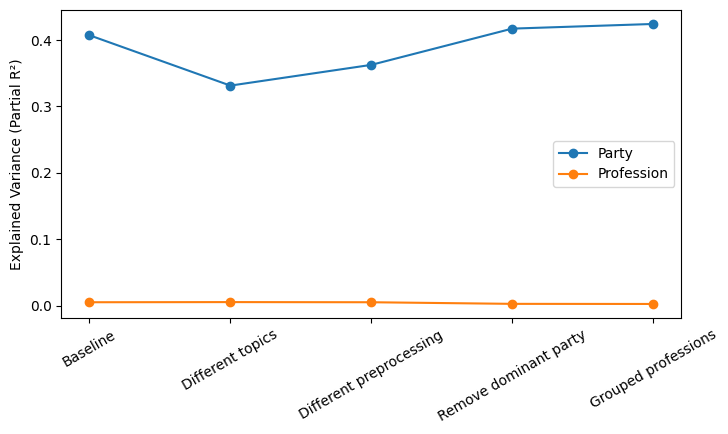

In [16]:
# plot robustness results
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(robustness_table["Test"], robustness_table["Party_R2"], marker="o", label="Party")
plt.plot(robustness_table["Test"], robustness_table["Profession_R2"], marker="o", label="Profession")

plt.xticks(rotation=30)
plt.ylabel("Explained Variance (Partial R²)")
plt.legend()

plt.show()

In [17]:
# permutation test to check if observed R² contributions are significantly higher than random chance
# This is a computationally intensive test, so we run it with fewer permutations for demonstration purposes. 
# In practice, we would want to run it with more permutations (e.g. 1000) for more reliable results.
import numpy as np

def permutation_test(X, df, k=10, n_perm=50):

    permuted_r2 = []

    for i in range(n_perm):

        df_perm = df.copy()

        # shuffle party labels
        df_perm["party_clean"] = np.random.permutation(df_perm["party_clean"])

        party_r2, _ = run_topic_regression(X, df_perm, k)

        permuted_r2.append(party_r2)

    return permuted_r2

In [ ]:
permuted_results = permutation_test(X, df, k=10, n_perm=50)

# 8mins

In [19]:
print("Permutation test results (Party R² contributions under null hypothesis):")  
print(np.mean(permuted_results))

Permutation test results (Party R² contributions under null hypothesis):
0.002630908994178985


In [20]:
p_value = np.mean(np.array(permuted_results) >= baseline_party)
print("P-value for observed Party R² contribution:")
print(p_value)

P-value for observed Party R² contribution:
0.0


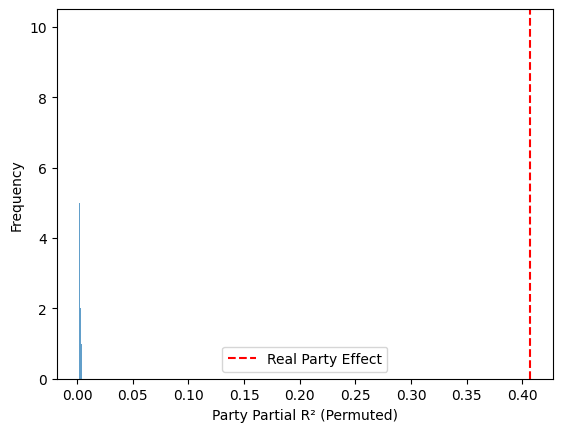

In [21]:
import matplotlib.pyplot as plt

plt.hist(permuted_results, bins=15, alpha=0.7)
plt.axvline(baseline_party, color='red', linestyle='--', label='Real Party Effect')

plt.xlabel("Party Partial R² (Permuted)")
plt.ylabel("Frequency")
plt.legend()

plt.show()